# RQ4: uncertainty propagation and robustness of the RQ2/RQ3 conclusions

Scrambled-Sobol Monte Carlo (N = 4096) through the coupled physics model at fixed operating points (control not
re-solved per sample). Uncertainty groups (`data/uq/uncertainty_spec.yaml`): kinetics (Xu-Froment 95 % intervals,
effectiveness multiplier, activity), heat transfer/furnace (calibration covariance of F_gt, L_q, f_htg; structural
variant L_q_eff = L_q x load^0.5), creep (heat-to-heat scatter sigma_log10 = 0.3, Larson-Miller C +/- 1, wall 12-18 mm,
tube conductivity +/-15 %), measurement (tube-wall temperature offset +/-10 K). The base point is evaluated with the
same samples so that life ratios are paired. Variance decomposition by freezing all groups but one (N = 1024 each) plus
Sobol indices on a GP surrogate of the joint sample. Life uses the **Yeh Manaurite XM placeholder** curve.
Results computed by `rdt.uq` (`data/uq/`) and `rdt.steam_credit` (`data/optimization/steam_credit_v1.json`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdt import uq

pd.set_option("display.width", 250)
S = json.loads((uq.OUT_DIR / "uq_summary_v1.json").read_text())
names = ["S1_base", "RQ3_knee", "RQ3_min_life_iso_H2", "S5_y4_holdslip_end", "S6_SC2.5", "S6_SC3.5", "load_0.70", "load_0.85"]
print("N =", S["N"], "; convergence:", {k: round(v, 4) for k, v in S["convergence"].items()})
rows = []
for n in names:
    iv = S["intervals"][n]; nom = S["nominal_runs"][n]
    rows.append({"point": n, "T_wo_max nominal": nom["T_wo_max_K"], "T_wo_max median": iv["T_wo_max_K"]["median"], "T_wo_max p05": iv["T_wo_max_K"]["p05"], "T_wo_max p95": iv["T_wo_max_K"]["p95"], "T_wo 90% width": iv["T_wo_max_K"]["width_90"],
                 "T_out median": iv["T_out_K"]["median"], "T_out p05": iv["T_out_K"]["p05"], "T_out p95": iv["T_out_K"]["p95"],
                 "CH4 slip median": iv["CH4_slip_dry_pct"]["median"], "slip p05": iv["CH4_slip_dry_pct"]["p05"], "slip p95": iv["CH4_slip_dry_pct"]["p95"],
                 "log10 t_r nominal": nom["log10_t_r"], "log10 t_r median": iv["log10_t_r"]["median"], "log10 t_r p05": iv["log10_t_r"]["p05"], "log10 t_r p95": iv["log10_t_r"]["p95"],
                 "life/kmol rel base median": iv["life_rate_per_kmol_H2_rel_base"]["median"], "rel p05": iv["life_rate_per_kmol_H2_rel_base"]["p05"], "rel p95": iv["life_rate_per_kmol_H2_rel_base"]["p95"]})
tab = pd.DataFrame(rows).set_index("point"); print(tab.T.to_string(float_format=lambda v: f"{v:.3f}"))
print("\nnominal run inside the 5-95 % interval:", S["nominal_inside_90pct_interval"])
print("\nvariance shares (S1 base):"); print(pd.DataFrame({c: v["shares"] for c, v in S["variance_shares_S1_base"].items()}).round(3).to_string())
print({c: {"sum": round(v["sum_of_shares"], 3), "interaction_residual": round(v["interaction_residual"], 3)} for c, v in S["variance_shares_S1_base"].items()})
sob = S.get("sobol_on_surrogate_S1_base", {})
if "error" not in sob:
    print("\nSobol on GP surrogate of the joint sample (group totals):")
    for c, v in sob.items(): print(f"  {c}: R2 {v['surrogate_R2_on_joint']:.3f}; ST {dict((k, round(x, 3)) for k, x in v['group_ST'].items())}; S1 {dict((k, round(x, 3)) for k, x in v['group_S1'].items())}")
print("\nrobustness fractions:"); print(pd.DataFrame(S["robustness_fractions"]).round(3).to_string())
print("\nL_q-variant intervals (life per kmol rel base):", {n: {k: round(v, 3) for k, v in S["intervals_lq_variant"][n]["life_rate_per_kmol_H2_rel_base"].items()} for n in S["intervals_lq_variant"]})


N = 4096 ; convergence: {'S1_base': 1.0, 'RQ3_knee': 1.0, 'RQ3_min_life_iso_H2': 1.0, 'S5_y4_holdslip_end': 1.0, 'S6_SC2.5': 1.0, 'S6_SC3.5': 1.0, 'load_0.70': 1.0, 'load_0.85': 1.0, 'load_1.00': 1.0}
point                      S1_base  RQ3_knee  RQ3_min_life_iso_H2  S5_y4_holdslip_end  S6_SC2.5  S6_SC3.5  load_0.70  load_0.85
T_wo_max nominal          1144.813  1125.575             1121.073            1165.246  1145.585  1143.613   1137.499   1140.906
T_wo_max median           1146.507  1127.120             1122.552            1166.982  1147.294  1145.240   1139.090   1142.595
T_wo_max p05              1127.994  1102.489             1100.191            1139.779  1129.677  1126.999   1123.683   1125.261
T_wo_max p95              1170.243  1158.976             1152.177            1205.384  1167.629  1173.687   1156.976   1163.374
T_wo 90% width              42.250    56.487               51.986              65.605    37.952    46.688     33.293     38.113
T_out median              1105.

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig14_uq_distributions.png


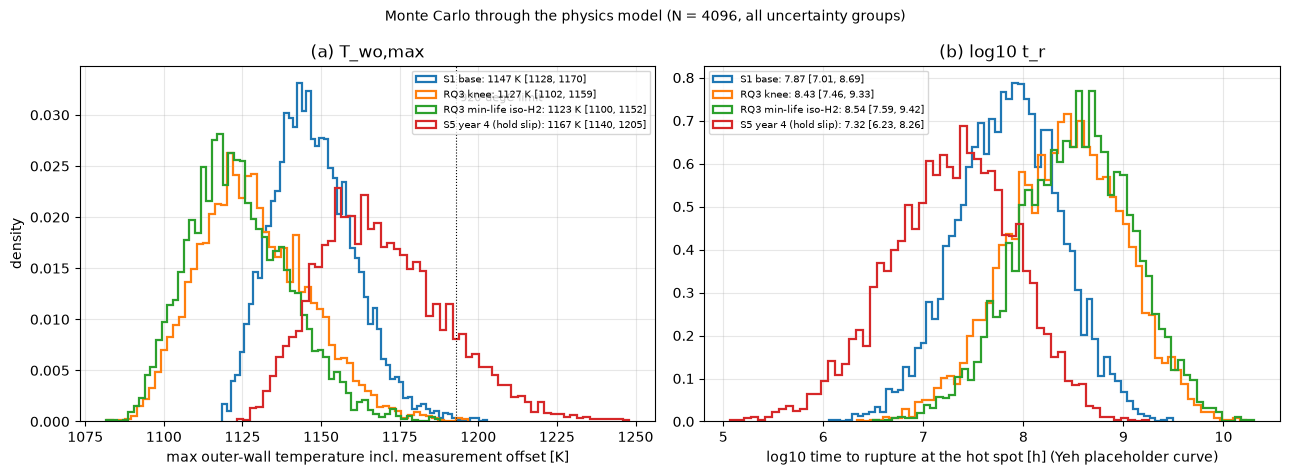

In [2]:
mc = {n: pd.read_csv(uq.OUT_DIR / f"mc_v1_{n}.csv.gz") for n in ("S1_base", "RQ3_knee", "RQ3_min_life_iso_H2", "S5_y4_holdslip_end")}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
labels = {"S1_base": "S1 base", "RQ3_knee": "RQ3 knee", "RQ3_min_life_iso_H2": "RQ3 min-life iso-H2", "S5_y4_holdslip_end": "S5 year 4 (hold slip)"}
for n, d in mc.items():
    d = d[d.converged == True]
    ax[0].hist(d.T_wo_max_K, bins=60, histtype="step", lw=1.6, label=f"{labels[n]}: {np.median(d.T_wo_max_K):.0f} K [{np.percentile(d.T_wo_max_K, 5):.0f}, {np.percentile(d.T_wo_max_K, 95):.0f}]", density=True)
    ax[1].hist(d.log10_t_r, bins=60, histtype="step", lw=1.6, label=f"{labels[n]}: {np.median(d.log10_t_r):.2f} [{np.percentile(d.log10_t_r, 5):.2f}, {np.percentile(d.log10_t_r, 95):.2f}]", density=True)
ax[0].axvline(1193, color="k", ls=":", lw=0.8); ax[0].text(1193, ax[0].get_ylim()[1] * 0.9, " 920 degC limit", fontsize=8)
ax[0].set_xlabel("max outer-wall temperature incl. measurement offset [K]"); ax[0].set_ylabel("density"); ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3); ax[0].set_title("(a) T_wo,max")
ax[1].set_xlabel("log10 time to rupture at the hot spot [h] (Yeh placeholder curve)"); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3); ax[1].set_title("(b) log10 t_r")
fig.suptitle(f"Monte Carlo through the physics model (N = {S['N']}, all uncertainty groups)", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig14_uq_distributions.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig15_variance_shares.png


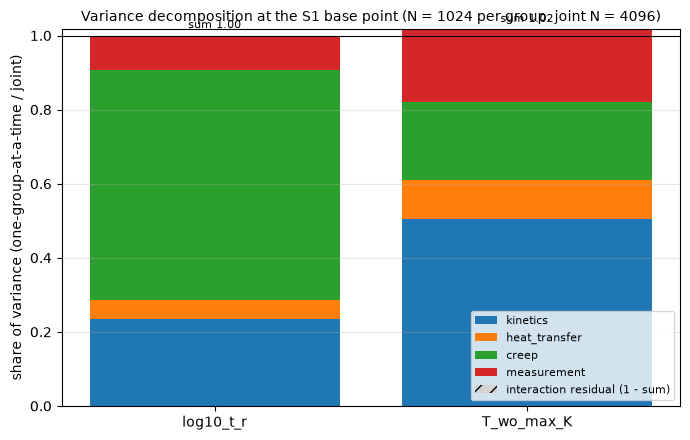

In [3]:
vs = S["variance_shares_S1_base"]
fig, ax = plt.subplots(figsize=(7, 4.5))
cols = ["log10_t_r", "T_wo_max_K"]; groups = list(uq.GROUPS); bottom = np.zeros(len(cols))
for g in groups:
    vals = np.array([vs[c]["shares"][g] for c in cols]); ax.bar(cols, vals, bottom=bottom, label=g); bottom += vals
resid = np.array([vs[c]["interaction_residual"] for c in cols])
ax.bar(cols, np.maximum(resid, 0), bottom=bottom, color="lightgrey", hatch="//", label="interaction residual (1 - sum)")
ax.axhline(1.0, color="k", lw=0.8); ax.set_ylabel("share of variance (one-group-at-a-time / joint)"); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
ax.set_title("Variance decomposition at the S1 base point (N = 1024 per group, joint N = 4096)", fontsize=10)
for i, c in enumerate(cols): ax.text(i, bottom[i] + max(resid[i], 0) + 0.02, f"sum {vs[c]['sum_of_shares']:.2f}", ha="center", fontsize=8)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig15_variance_shares.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


 alpha_credit   regime  steam_to_carbon  load  firing  inlet_T  excess_air  life_rel_base  fuel_total_rel_base_pct  T_wo_max_K  H2_rel_base_pct
         0.00 min_life            3.999 0.959   0.883  896.475      18.023          0.072                    1.517    1109.593           -0.953
         0.00 min_fuel            2.758 0.988   0.900  899.929       5.003          3.501                   -7.624    1170.347           -0.937
         0.00     knee            3.281 0.977   0.851  899.995       5.001          0.702                   -6.092    1144.312           -0.984
         0.25 min_life            3.998 0.959   0.850  899.976      13.157          0.090                   -3.436    1112.850           -0.893
         0.25 min_fuel            3.287 0.977   0.850  900.000       5.000          0.687                   -7.837    1143.972           -0.992
         0.25     knee            3.833 0.944   0.850  900.000       5.000          0.286                   -6.430    1130.418          

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig13_steam_credit.png


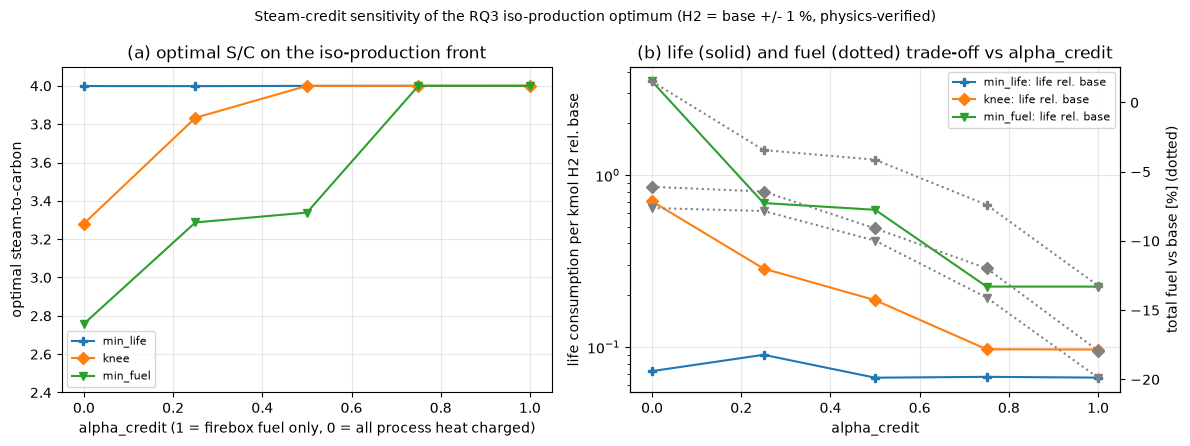

In [4]:
sc_ = json.loads((Path("..") / "data" / "optimization" / "steam_credit_v1.json").read_text())
alphas = [float(a) for a in sc_["alphas"]]; pa = sc_["per_alpha"]
rows = []
for a in alphas:
    r = pa[str(a)]
    for lab in ("min_life", "min_fuel", "knee"):
        if lab in r: rows.append({"alpha_credit": a, "regime": lab, **r[lab]})
tab = pd.DataFrame(rows); print(tab.round(3).to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for lab, mk in (("min_life", "P"), ("knee", "D"), ("min_fuel", "v")):
    t = tab[tab.regime == lab]
    ax[0].plot(t.alpha_credit, t.steam_to_carbon, marker=mk, label=lab); ax[1].plot(t.alpha_credit, t.life_rel_base, marker=mk, label=f"{lab}: life rel. base")
ax[0].set_xlabel("alpha_credit (1 = firebox fuel only, 0 = all process heat charged)"); ax[0].set_ylabel("optimal steam-to-carbon"); ax[0].set_ylim(2.4, 4.1); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8); ax[0].set_title("(a) optimal S/C on the iso-production front")
ax[1].set_yscale("log"); ax[1].set_ylabel("life consumption per kmol H2 rel. base"); ax[1].set_xlabel("alpha_credit"); ax[1].grid(alpha=0.3)
ax2 = ax[1].twinx()
for lab, mk in (("min_life", "P"), ("knee", "D"), ("min_fuel", "v")):
    t = tab[tab.regime == lab]; ax2.plot(t.alpha_credit, t.fuel_total_rel_base_pct, marker=mk, ls=":", color="grey")
ax2.set_ylabel("total fuel vs base [%] (dotted)"); ax[1].legend(fontsize=8); ax[1].set_title("(b) life (solid) and fuel (dotted) trade-off vs alpha_credit")
fig.suptitle("Steam-credit sensitivity of the RQ3 iso-production optimum (H2 = base +/- 1 %, physics-verified)", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig13_steam_credit.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()
